In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import wilcoxon
from scipy.stats import norm
from scipy.stats import sem
import seaborn as sns

In [27]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [28]:
df = pd.read_csv(filtered_data / "text_messages_filtered.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df[df["is_donor"] == 1]

In [29]:
exclude_donors = [
    "06b923ca-4d2d-44bb-8b20-4e2c9b08ce9f",
    "179bbc95-ec8b-4a65-98c5-5d3b566806fa",
]

df = df[~df["donation_id"].isin(exclude_donors)]

all_donors = df["donation_id"].unique()
war_date = pd.to_datetime("2022-02-24")

#### Two-month time periods (±6 months around Feb 24, 2022)

In [30]:
periods = [
    war_date - pd.DateOffset(months=6),   
    war_date - pd.DateOffset(months=4),  
    war_date - pd.DateOffset(months=2),
    war_date,                              
    war_date + pd.DateOffset(months=2),  
    war_date + pd.DateOffset(months=4),   
    war_date + pd.DateOffset(months=6),   
]

In [31]:
# message share per chat in a given period
def build_weights(df_donor, start, end, chat_list):
    df_p = df_donor[
        (df_donor["datetime"] >= start) &
        (df_donor["datetime"] < end)
    ]
    counts = df_p.groupby("conversation_id").size()
    total = counts.sum()
    if total == 0:
        return {chat: 0 for chat in chat_list}, 0
    weights = {chat: counts.get(chat, 0) / total for chat in chat_list}
    return weights, total

In [32]:
def gini(values):
    arr = np.array(values)
    if arr.sum() == 0:
        return 0
    arr = np.sort(arr)
    n = len(arr)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * arr) / (n * arr.sum())) - (n + 1) / n

In [33]:
def build_pos(top_chats, radius=1.0):
    pos = {"Donor": (0, 0)}
    labels = {"Donor": "Donor"}
    for i, chat in enumerate(top_chats):
        angle = 2 * np.pi * i / len(top_chats)
        pos[chat] = (radius * np.cos(angle), radius * np.sin(angle))
        labels[chat] = f"C{i+1}"
    return pos, labels

In [34]:
def draw_network_row(weights_list, totals_list, periods, pos, labels, top_chats):
    fig, axes = plt.subplots(1, len(weights_list), figsize=(27, 4.6))
    max_weight = max(max(w.values()) for w in weights_list) or 1

    for i, (weights, total) in enumerate(zip(weights_list, totals_list)):
        G = nx.Graph()
        G.add_node("Donor")
        for chat in top_chats:
            G.add_node(chat)
            if weights[chat] > 0:
                G.add_edge("Donor", chat, weight=weights[chat])

        edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
        widths = [(w / max_weight) * 10 for w in edge_weights]
        node_sizes = [400 if n == "Donor" else 80 for n in G.nodes()]
        node_colors = ["red" if n == "Donor" else "lightgray" for n in G.nodes()]

        nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, edgecolors="black", linewidths=0.5, ax=axes[i])
        nx.draw_networkx_edges(G, pos, width=widths, edge_color="black", alpha=0.8, ax=axes[i])

        offset = 0.14
        label_pos = {}
        for node, (x, y) in pos.items():
            if node == "Donor":
                continue
            norm = np.sqrt(x**2 + y**2)
            label_pos[node] = (x + offset * x / norm, y + offset * y / norm)

        nx.draw_networkx_labels(G, label_pos, labels={k: v for k, v in labels.items() if k != "Donor"}, font_size=8, ax=axes[i])

        start_str = periods[i].strftime("%b %d")
        end_str = periods[i + 1].strftime("%b %d")
        axes[i].set_title(f"{start_str} – {end_str}\nMessages: {total}", fontsize=18)
        axes[i].axis("off")
        axes[i].set_xlim(-1.35, 1.35)
        axes[i].set_ylim(-1.35, 1.35)

    plt.tight_layout()
    plt.show()

### Network graph (one donor)

In [35]:
donor_idx = 10
top_n_chats = 30

In [36]:
donor_id = all_donors[donor_idx]
df_donor = df[df["donation_id"] == donor_id].copy()

pre_start = war_date - pd.DateOffset(months=6)
post_end = war_date + pd.DateOffset(months=6)

df_donor = df_donor[
    (df_donor["datetime"] >= pre_start) &
    (df_donor["datetime"] <= post_end)
].copy()


In [37]:
top_chats = (
    df_donor.groupby("conversation_id")
    .size()
    .sort_values(ascending=False)
    .head(top_n_chats)
    .index
    .tolist()
)

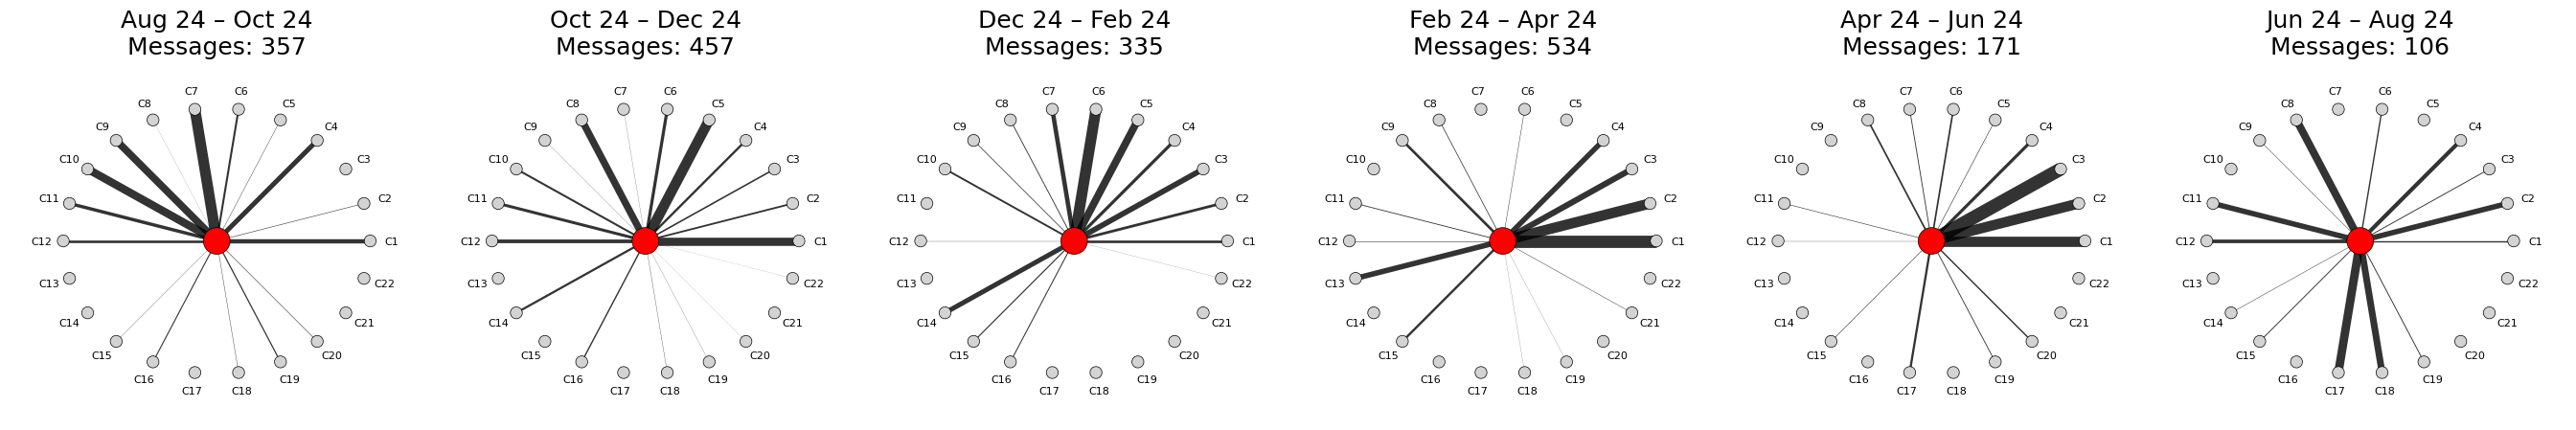

In [38]:
pos, labels = build_pos(top_chats)

weights_list, totals_list = [], []
for i in range(len(periods) - 1):
    w, t = build_weights(df_donor, periods[i], periods[i+1], top_chats)
    weights_list.append(w)
    totals_list.append(t)

draw_network_row(weights_list, totals_list, periods, pos, labels, top_chats)


### Gini index - all donors

In [39]:
top_n_chats_gini = 30

In [40]:
pre_start = war_date - pd.DateOffset(months=6)
post_end  
rows = []

for donor_id in all_donors:
    df_donor = df[df["donation_id"] == donor_id]
    if df_donor.empty:
        continue

    df_donor = df_donor[
        (df_donor["datetime"] >= pre_start) &
        (df_donor["datetime"] <= post_end)
    ]

    if df_donor.empty:
        continue

    top_chats = (
        df_donor.groupby("conversation_id")
        .size()
        .sort_values(ascending=False)
        .head(top_n_chats_gini)
        .index
        .tolist()
    )

    donor_gini = [
        gini(list(build_weights(df_donor, periods[i], periods[i+1], top_chats)[0].values()))
        for i in range(len(periods) - 1)
    ]

    row = {f"P{i+1}": donor_gini[i] for i in range(len(donor_gini))}
    row["donor_id"] = donor_id
    rows.append(row)

gini_df = pd.DataFrame(rows)
gini_array = gini_df.drop(columns=["donor_id"]).values
print(f"Donors: {len(gini_df)}")


Donors: 22


In [41]:
n_periods = len(periods) - 1  
half = n_periods // 2        

pre_cols = [f"P{i+1}" for i in range(half)]
post_cols = [f"P{i+1}" for i in range(half, n_periods)]

gini_pre_mean = gini_df[pre_cols].mean(axis=1).values
gini_post_mean = gini_df[post_cols].mean(axis=1).values

print(f"Average Gini pre: {gini_pre_mean.mean():.4f}")
print(f"Average Gini post: {gini_post_mean.mean():.4f}")


Average Gini pre: 0.7593
Average Gini post: 0.7400


#### Boxplot: Gini pre vs Gini post

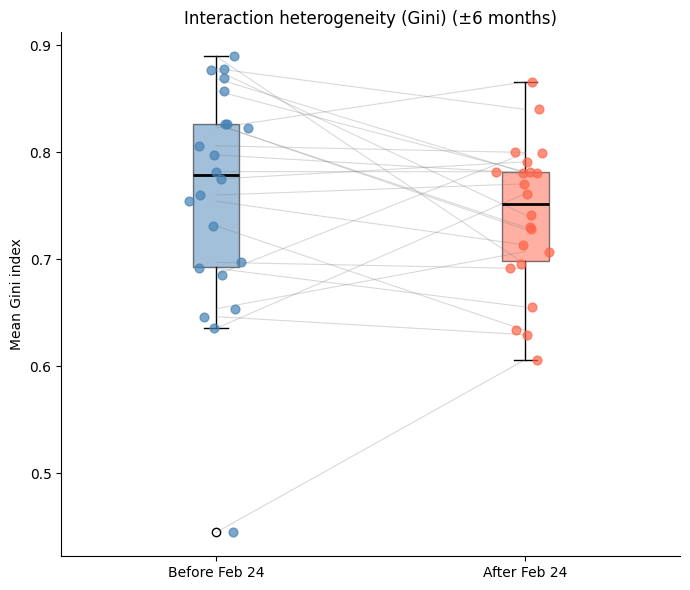

In [42]:
fig, ax = plt.subplots(figsize=(7, 6))

bp = ax.boxplot([gini_pre_mean, gini_post_mean],
                labels=['Before Feb 24', 'After Feb 24'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.5)
bp['boxes'][1].set_facecolor('tomato')
bp['boxes'][1].set_alpha(0.5)

x_pre  = np.random.normal(1, 0.04, len(gini_pre_mean))
x_post = np.random.normal(2, 0.04, len(gini_post_mean))
ax.scatter(x_pre,  gini_pre_mean,  color='steelblue', alpha=0.7, zorder=5, s=40)
ax.scatter(x_post, gini_post_mean, color='tomato', alpha=0.7, zorder=5, s=40)

for pre, post in zip(gini_pre_mean, gini_post_mean):
    ax.plot([1, 2], [pre, post], color='gray', alpha=0.3, linewidth=0.8)

ax.set_ylabel('Mean Gini index')
ax.set_title('Interaction heterogeneity (Gini) (±6 months)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


#### Wilcoxon Signed-Rank Test: Gini pre vs post

In [43]:
stat, p = wilcoxon(gini_pre_mean, gini_post_mean)

n = len(gini_pre_mean)
z = norm.ppf(p / 2)
r = abs(z) / np.sqrt(n)

sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
direction = 'increased' if gini_post_mean.mean() > gini_pre_mean.mean() else 'decreased'

print('Wilcoxon Signed-Rank Test — Gini pre vs post')
print(f'n = {n} donors')
print(f'Mean Gini pre: {gini_pre_mean.mean():.4f}')
print(f'Mean Gini post: {gini_post_mean.mean():.4f}')
print(f'W = {stat:.1f}')
print(f'p = {p:.4f} {sig}')
print(f'Effect size r = {r:.3f}')
print(f'Direction: Gini {direction} after invasion')

Wilcoxon Signed-Rank Test — Gini pre vs post
n = 22 donors
Mean Gini pre: 0.7593
Mean Gini post: 0.7400
W = 90.0
p = 0.2479 n.s.
Effect size r = 0.246
Direction: Gini decreased after invasion


#### Social Signature

In [44]:
top_n_ranks = 6

In [45]:
def get_signature(df_donor, start, end, top_n):
    df_p = df_donor[
        (df_donor["datetime"] >= start) &
        (df_donor["datetime"] < end)
    ]
    if df_p.empty:
        return None

    counts = df_p.groupby("conversation_id").size()
    total = counts.sum()
    if total == 0:
        return None

    fractions = (counts / total).sort_values(ascending=False)

    sig = fractions.values[:top_n]
    if len(sig) < top_n:
        sig = np.pad(sig, (0, top_n - len(sig)))
    return sig

In [46]:
pre_start = war_date - pd.DateOffset(months=6)
post_end = war_date + pd.DateOffset(months=6)

sigs_pre = []
sigs_post = []

for donor_id in all_donors:
    df_donor = df[df["donation_id"] == donor_id]
    if df_donor.empty:
        continue

    sig_pre = get_signature(df_donor, pre_start, war_date, top_n_ranks)
    sig_post = get_signature(df_donor, war_date, post_end, top_n_ranks)

    if sig_pre is not None and sig_post is not None:
        sigs_pre.append(sig_pre)
        sigs_post.append(sig_post)

sigs_pre = np.array(sigs_pre) 
sigs_post = np.array(sigs_post)

print(f"Shape: {sigs_pre.shape}")
print(f"\nAverage signature pre: {sigs_pre.mean(axis=0).round(3)}")
print(f"nAverage signature post: {sigs_post.mean(axis=0).round(3)}")


Shape: (22, 6)

Average signature pre: [0.371 0.145 0.084 0.067 0.052 0.044]
nAverage signature post: [0.295 0.156 0.106 0.079 0.059 0.046]


In [47]:
ranks = np.arange(1, top_n_ranks + 1)

mean_pre = sigs_pre.mean(axis=0)
mean_post = sigs_post.mean(axis=0)

se_pre = sem(sigs_pre, axis=0) 
se_post = sem(sigs_post, axis=0)

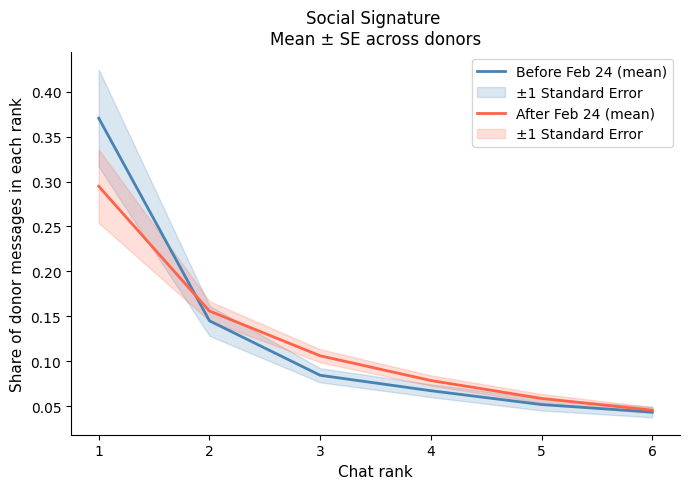

In [48]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(ranks, mean_pre, color='steelblue', linewidth=2, label='Before Feb 24 (mean)')
ax.fill_between(ranks, mean_pre - se_pre, mean_pre + se_pre, alpha=0.2, color='steelblue', label='±1 Standard Error')

ax.plot(ranks, mean_post, color='tomato', linewidth=2, label='After Feb 24 (mean)')
ax.fill_between(ranks, mean_post - se_post, mean_post + se_post, alpha=0.2, color='tomato', label='±1 Standard Error')

ax.set_xlabel('Chat rank', fontsize=11)
ax.set_ylabel('Share of donor messages in each rank', fontsize=11)
ax.set_title('Social Signature \n'
             'Mean ± SE across donors', fontsize=12)
ax.set_xticks(ranks)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [49]:
delta = sigs_post - sigs_pre 
mean_delta = delta.mean(axis=0)
se_delta = sem(delta, axis=0)

#### Delta heatmap per donor

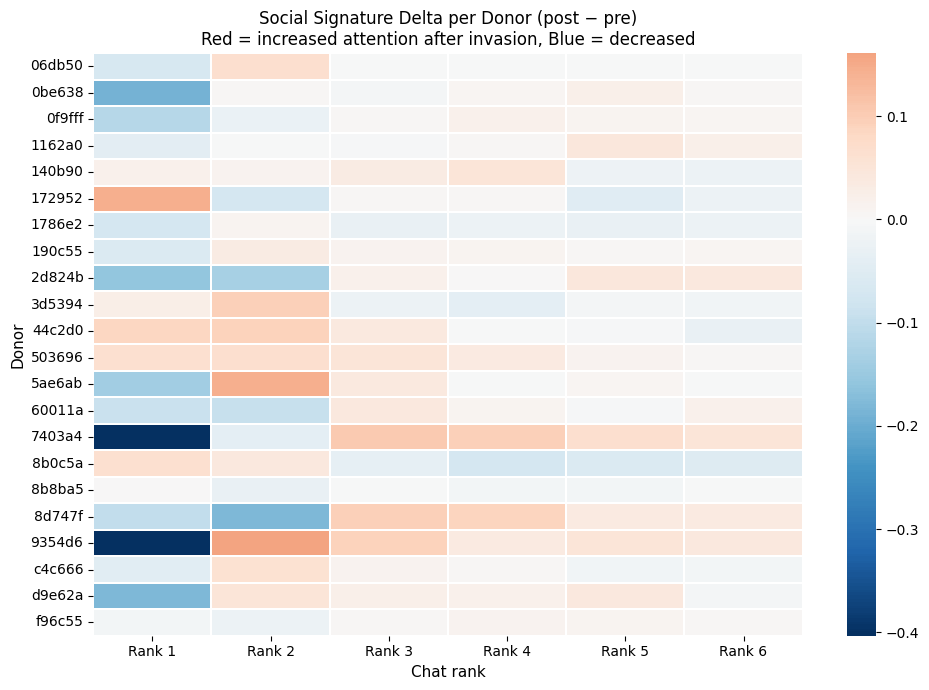

In [50]:
donor_labels = []
for donor_id in all_donors:
    df_donor = df[df["donation_id"] == donor_id]
    if df_donor.empty:
        continue
    sig_pre = get_signature(df_donor, pre_start, war_date, top_n_ranks)
    sig_post = get_signature(df_donor, war_date,  post_end,  top_n_ranks)
    if sig_pre is not None and sig_post is not None:
        donor_labels.append(donor_id[:6])

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    delta,
    cmap='RdBu_r',
    center=0,
    # annot=True,
    # fmt='.2f',
    linewidths=0.3,
    xticklabels=[f'Rank {r}' for r in ranks],
    yticklabels=donor_labels,
    ax=ax
)

ax.set_xlabel('Chat rank', fontsize=11)
ax.set_ylabel('Donor', fontsize=11)
ax.set_title('Social Signature Delta per Donor (post − pre)\nRed = increased attention after invasion, Blue = decreased', fontsize=12)
plt.tight_layout()
plt.show()